# Eigenvector Testing

In [43]:
%load_ext autoreload
%autoreload 2

import numpy as np
    
import matplotlib.pyplot as plt
import inspect

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [44]:
from pyabs.core.basis import ABSBasisConfig, build_abs_basis
from pyabs.core.matrix import build_abs_matrix
from pyabs.core.wake import ThetaWake, WakeScale
from pyabs.solvers.eigensolvers import solve_eigenvalues, solve_eigensystem, solve_system, solve_antheta, solve_azimuthal

In [45]:
n_max=21
basis = build_abs_basis(np, ABSBasisConfig(n_max=n_max, q=0))

In [46]:
theta_wake = ThetaWake(W0=0.7)

In [47]:
matrix = build_abs_matrix(basis, wake_model=theta_wake, scale=WakeScale(w = 1))

In [48]:
#eigenvalue_i, eigenvectors_i 
eigensolution = solve_eigensystem(matrix)
eigenvalues = np.array(eigensolution.eigenvalues)
eigenvectors= np.array(eigensolution.eigenvectors)

In [50]:
print(eigenvectors.shape)
#print(eigenvalues[0])
print(eigenvectors)
tvec = eigenvectors.transpose()
#print(tvec[:,0])

(43, 43)
[[ 2.65092963e-07+6.54695762e-19j  2.76652160e-06-3.41491538e-19j
   7.05144663e-05+4.06575815e-19j ... -9.43599741e-04-2.33473011e-18j
  -5.28309304e-03-1.08420217e-17j  9.99997822e-01+0.00000000e+00j]
 [ 8.46348822e-05-6.34707702e-17j  4.52391722e-07-3.01748340e-17j
   3.13661223e-06+1.97724807e-16j ... -5.56055518e-03-3.84392135e-16j
   9.99983625e-01+0.00000000e+00j -1.71746287e-03+5.11294660e-18j]
 [ 2.17626682e-05+1.60729975e-16j  9.35854546e-05-1.35452257e-16j
   4.97763155e-07+4.67058149e-16j ...  9.99981410e-01+0.00000000e+00j
  -1.81429359e-03+8.12934789e-16j  8.70862608e-04-1.07832215e-18j]
 ...
 [ 8.38886007e-04+3.12517679e-15j  5.37445001e-03-4.03418812e-15j
   9.99980371e-01+0.00000000e+00j ... -5.45937675e-08+3.94425999e-16j
  -2.41049038e-06-8.30223578e-17j  6.34822954e-05+1.38916065e-19j]
 [ 5.11360995e-03-7.81776414e-15j  9.99982666e-01+0.00000000e+00j
   1.80194016e-03+5.27312569e-15j ...  9.34591333e-05+1.69855165e-16j
   1.27370111e-08+8.61157031e-17j -1.7

In [56]:
solution = solve_system(matrix);
#solution.compute(1)
solution.compute_x(0, 0)
solution.compute_centroid(1)

np.complex128(52.98399523370982+2.0528023725319144e-13j)

In [52]:
antest = solve_antheta(eigensolution)
antest(2)

array([-0.3966364 -0.92234267j, -0.67043845+0.74318779j,
        0.95721949+0.29657781j, -0.12544124-0.99757003j,
       -0.85197877+0.52552676j,  0.83552952+0.55237164j,
        0.1585242 -0.99424947j, -0.96628058+0.26534439j,
        0.64716342+0.7639582j ,  0.43044963-0.91207973j,
       -1.00336798-0.01745255j,  0.40633117+0.91451479j,
        0.66961612-0.75762737j, -0.96011657-0.30180385j,
        0.13160129+0.99212408j,  0.85809206-0.54386795j,
       -0.83710902-0.56855408j, -0.16040894+0.98823332j,
        0.99164919-0.28478511j, -0.62554793-0.84022935j,
       -0.45625521+1.01635256j,  0.64483545-0.91371686j,
       -0.21422793-1.0218965j , -0.63724018+0.75642348j,
        0.94565371+0.27206963j, -0.14594542-0.96968874j,
       -0.83000285+0.55099107j,  0.83894189+0.53457131j,
        0.13180216-0.98001314j, -0.9515871 +0.29564774j,
        0.65861552+0.74908473j,  0.40298687-0.90622207j,
       -0.99623431+0.01588979j,  0.42436789+0.90448586j,
        0.64213073-0.75856364j,

In [53]:
aztest = solve_azimuthal(eigensolution)
aztest(1)

array([-0.54772926-0.83665564j,  0.40808206-0.91294525j,
        0.98870462-0.14987721j,  0.66031671+0.75098725j,
       -0.27516334+0.96139749j, -0.95765948+0.28790332j,
       -0.75968791-0.65028784j,  0.13673722-0.99060736j,
        0.90744678-0.42016704j,  0.84385396+0.53657292j,
        0.0044257 +0.99999021j, -0.83907153+0.54402111j,
       -0.91113026-0.41211849j, -0.14550003-0.98935825j,
        0.75390225-0.6569866j ,  0.96017029+0.2794155j ,
        0.28366219+0.95892427j, -0.65364362+0.7568025j ,
       -0.9899925 -0.14112001j, -0.41614684-0.90929743j,
        0.54030231-0.84147098j,  1.        +0.j        ,
        0.54030231+0.84147098j, -0.41614684+0.90929743j,
       -0.9899925 +0.14112001j, -0.65364362-0.7568025j ,
        0.28366219-0.95892427j,  0.96017029-0.2794155j ,
        0.75390225+0.6569866j , -0.14550003+0.98935825j,
       -0.91113026+0.41211849j, -0.83907153-0.54402111j,
        0.0044257 -0.99999021j,  0.84385396-0.53657292j,
        0.90744678+0.42016704j,

In [99]:
sc = np.linspace(0, 2, num=600)
modes = np.arange(-n_max, (n_max)+1, dtype=int)
eigenscan_val = []
eigenscan_vec = []
for i, q in enumerate(sc):
    basis = build_abs_basis(np, ABSBasisConfig(n_max=n_max, q=q))
    matrix = build_abs_matrix(basis, wake_model=theta_wake, scale=WakeScale(w = 1))
    eigenscan_val.append(np.array(solve_eigensystem(matrix).eigenvalues))
    eigenscan_vec = (np.array(solve_eigensystem(matrix).eigenvectors))

In [100]:
#eigenscan=np.array(-np.imag(eigenscan)).T
im_eigenscan = np.array(-np.imag(eigenscan_val))
re_eigenscan = np.array(np.real(eigenscan_val))
im_eigenvec = np.array(-np.imag(eigenscan_vec))
re_eigenvec = np.array(np.real(eigenscan_vec))

re_eigenvec

array([[ 0.27861899,  0.27861899,  0.92377029],
       [ 0.13474827,  0.13474827, -0.00405238],
       [ 0.67941919,  0.67941919, -0.38292563]])

In [103]:
def sort_by_continuity(eigenscan):
    sorted_scan = eigenscan.copy()
    n_steps, n_modes = eigenscan.shape

    for i in range(1, n_steps):
        prev = sorted_scan[i - 1]
        curr = sorted_scan[i].copy()

        used = set()
        new_order = np.zeros(n_modes, dtype=int)
        for j in range(n_modes):
            # find the closest unused eigenvalue in curr to prev[j]
            dists = np.abs(curr - prev[j])
            dists[list(used)] = np.inf
            best = np.argmin(dists)
            new_order[j] = best
            used.add(best)

        sorted_scan[i] = curr[new_order]

    return sorted_scan

im_eigenscan_tracked = sort_by_continuity(im_eigenscan)
re_eigenscan_tracked = sort_by_continuity(re_eigenscan)
im_eigenvec_tracked = sort_by_continuity(im_eigenvec)
re_eigenvec_tracked = sort_by_continuity(re_eigenvec)

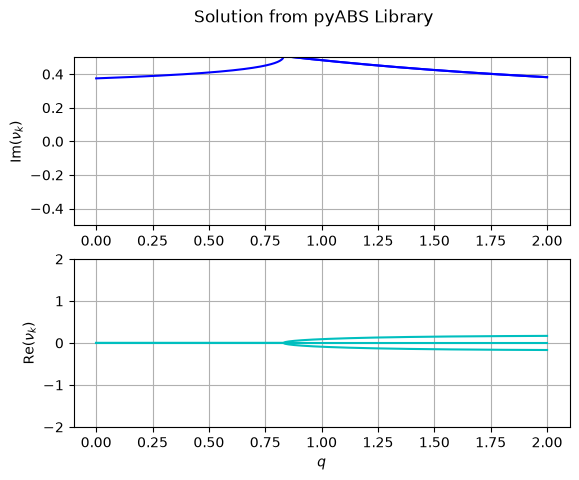

In [104]:
fig, ax = plt.subplots(2)
ax[0].set_ylim(-0.5,0.5)
ax[1].set_ylim(-2,2)
#ax[1].set_xlim(0,2)
#for i in range(len(modes)):
#    plt.scatter(sc, eigenscan[i])
plt.suptitle("Solution from pyABS Library")
ax[0].grid()
ax[1].grid()
ax[0].plot(sc, im_eigenscan_tracked, color='b')
ax[1].plot(sc, re_eigenscan_tracked, color='c')
ax[0].set_ylabel(r"Im($\nu_{k}$)")
ax[1].set_ylabel(r"Re($\nu_{k}$)")
ax[1].set_xlabel(r"$q$")
plt.savefig("../../plots/pyabs_theta.png", dpi=300)
plt.show()

ValueError: x and y must have same first dimension, but have shapes (600,) and (19, 19)

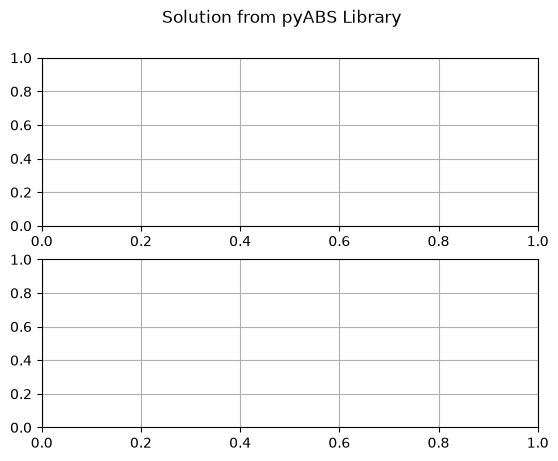

In [84]:
fig, ax = plt.subplots(2)
#ax[0].set_ylim(-0.5,0.5)
#ax[1].set_ylim(-2,2)
#ax[1].set_xlim(0,2)
#for i in range(len(modes)):
#    plt.scatter(sc, eigenscan[i])
plt.suptitle("Solution from pyABS Library")
ax[0].grid()
ax[1].grid()
ax[0].plot(sc, im_eigenvec_tracked, color='b')
ax[1].plot(sc, re_eigenvec_tracked, color='c')
ax[0].set_ylabel(r"Im($\nu_{k}$)")
ax[1].set_ylabel(r"Re($\nu_{k}$)")
ax[1].set_xlabel(r"$q$")
plt.savefig("../../plots/pyabs_theta.png", dpi=300)
plt.show()

compare with analytical solutions from burov
double check where the complex number went in burov

In [16]:
#analytic solutions
#analytic eigenvalues are given as
def real_eigen(n_max, q):
    modes = np.arange(-n_max, (n_max)+1, dtype=int)
    soln=[]
    for i in modes:
        if(i >= 0):
            soln.append(-q/2 + np.sqrt((q**2)/4 + i**2))
        if(i < 0):
            soln.append(-q/2 - np.sqrt((q**2)/4 + i**2))
    return soln

real_scan = []
#print(eigenscan_tracked)
analytical_solutions = []
for i, q in enumerate(sc):
    real_scan.append(real_eigen(n_max, q))
    


#print(eigenscan_tracked)
np.array(real_scan).shape

(600, 9)

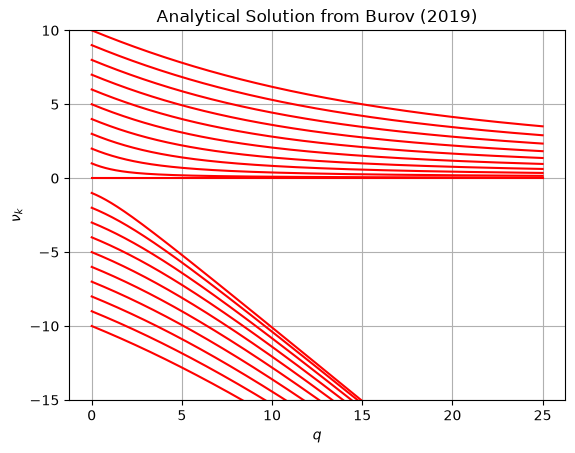

In [36]:
fig, ax = plt.subplots()
ax.set_ylim(-15,10)
plt.title("Analytical Solution from Burov (2019)")
plt.grid()
plt.plot(sc, real_scan, color='r')
ax.set_ylabel(r"$\nu_{k}$")
ax.set_xlabel(r"$q$")
plt.savefig("../../plots/analytical_nowake.png", dpi=300)
plt.show()

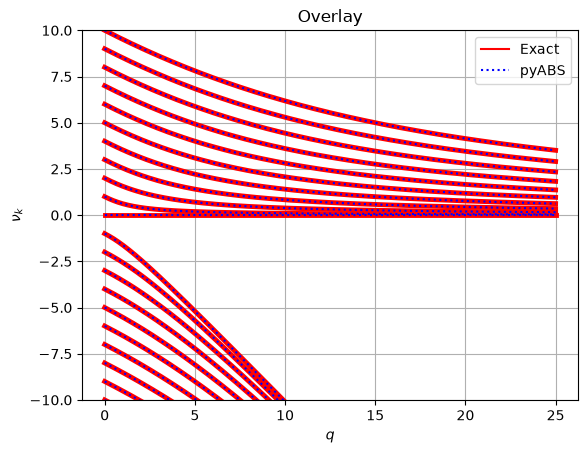

In [25]:
fig, ax = plt.subplots()
ax.set_ylim(-10,10)
plt.title("Overlay")
plt.grid()
plt.plot(sc, real_scan, color='r', lw=3.5)
plt.plot(sc, eigenscan_tracked, ':b')
plt.plot([],[], 'r', label='Exact')
plt.plot([],[], ':b', label="pyABS")
ax.legend()
ax.set_ylabel(r"$\nu_{k}$")
ax.set_xlabel(r"$q$")
plt.savefig("../../plots/overlay_nowake.png", dpi=300)
plt.show()